# Post-transcriptional regulation in breast cancer (CPTAC-BRCA)

**Question.** For each gene, how much does protein abundance deviate from what
its mRNA level would predict? That deviation (the protein-to-RNA ratio, PTR) is
a readout of *post-transcriptional regulation*.

**Approach.**
1. Load matched transcriptomics + proteomics for the same tumor samples (CPTAC-BRCA).
2. Align them by sample and by gene.
3. Compute the PTR gene by gene.
4. Train a model to predict protein from mRNA; the largest errors flag the most
   post-transcriptionally regulated genes.

**Step 01 - Acquisition.** Download the data and inspect what we received.


In [1]:
import cptac
import pandas as pd
import matplotlib.pyplot as plt
from importlib.metadata import version
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("cptac version:", version("cptac"))

cptac version: 1.5.14


## Load the BRCA dataset

`cptac.Brca()` gives us an object bundling every data type available for breast cancer (transcriptomics, proteomics, CNV, clinical...) for the same set of tumor samples. First we list which *source* provides which data type, since each measurement comes from a specific consortium lab.

In [2]:
brca = cptac.Brca()
brca.list_data_sources()

,Data type,Available sources
0,CNV,"[bcm, washu]"
1,miRNA,[bcm]
2,phosphoproteomics,"[bcm, umich]"
3,proteomics,"[bcm, umich]"
4,transcriptomics,"[bcm, broad, washu]"
5,ancestry_prediction,[harmonized]
6,somatic_mutation,"[harmonized, washu]"
7,clinical,[mssm]
8,follow-up,[mssm]
9,medical_history,[mssm]


# Section 1 — Data preprocessing

### Transcriptomics (mRNA)

We pull transcriptomics from the `bcm` source. 
Rows are tumor samples, columns are genes; each value is an mRNA abundance measurement. 
We use `bcm` for both mRNA and protein so the two tables share the same processing conventions.

In [3]:
rna = brca.get_transcriptomics(source="bcm")
print("shape:", rna.shape)
rna.head()

F:\BD\ptr-proteogenomics-brca\.venv\Lib\site-packages\cptac\cancers\bcm\bcmbrca.py:87: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  transcript = transcript.reset_index()


shape: (133, 60591)


Name,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,A3GALT2,...,ZXDB,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZYXP1,ZZEF1,hsa-mir-1253,hsa-mir-423
Database_ID,ENSG00000121410.12,ENSG00000268895.6,ENSG00000148584.15,ENSG00000175899.15,ENSG00000245105.4,ENSG00000166535.20,ENSG00000256661.1,ENSG00000256904.1,ENSG00000256069.7,ENSG00000184389.9,...,ENSG00000198455.4,ENSG00000070476.15,ENSG00000203995.10,ENSG00000232242.2,ENSG00000162378.13,ENSG00000159840.16,ENSG00000274572.1,ENSG00000074755.15,ENSG00000272920.1,ENSG00000266919.3
Patient_ID,,,,,,,,,,,,,,,,,,,,,
01BR001,3.51,8.04,0.00,12.93,5.01,4.88,0.0,0.0,3.13,0.0,...,9.02,8.88,7.07,0.0,9.86,10.63,0.0,10.05,0.0,0.0
01BR008,2.84,8.24,2.50,13.02,5.67,10.10,0.0,0.0,0.00,0.0,...,7.93,8.84,8.60,0.0,8.44,11.36,0.0,10.20,0.0,0.0
01BR009,4.85,8.11,0.00,13.68,5.87,9.50,0.0,0.0,3.11,0.0,...,7.53,8.85,3.64,0.0,8.90,10.58,0.0,10.54,0.0,0.0
01BR010,4.24,7.96,0.00,12.64,4.82,5.03,0.0,0.0,1.33,0.0,...,8.53,8.31,8.28,0.0,9.28,12.40,0.0,10.42,0.0,0.0
01BR015,3.89,7.56,1.58,13.55,5.32,3.31,0.0,0.0,2.99,0.0,...,9.17,9.05,5.08,0.0,10.13,10.44,0.0,10.46,0.0,0.0


### Proteomics

We pull proteomics from the same `bcm` source. Rows are tumor samples, columns are genes; each value is a protein abundance measurement. 
Two things to check: whether values are on the same log scale as mRNA, and how many entries are
missing (mass-spectrometry proteomics rarely measures every protein in every sample).

In [4]:
prot = brca.get_proteomics(source="bcm")
print("shape:", prot.shape)
prot.head()

shape: (122, 12021)


F:\BD\ptr-proteogenomics-brca\.venv\Lib\site-packages\cptac\cancers\bcm\bcmbrca.py:123: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  proteomics = proteomics.reset_index()


Name,A1BG,A2M,A2ML1,A4GALT,AAAS,AACS,AADAT,AAGAB,AAK1,AAMDC,...,ZSWIM8,ZSWIM9,ZUP1,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11B,ZYX,ZZEF1
Database_ID,ENSG00000121410.12,ENSG00000175899.15,ENSG00000166535.20,ENSG00000128274.17,ENSG00000094914.14,ENSG00000081760.17,ENSG00000109576.14,ENSG00000103591.13,ENSG00000115977.19,ENSG00000087884.14,...,ENSG00000214655.10,ENSG00000185453.13,ENSG00000153975.10,ENSG00000086827.9,ENSG00000174442.12,ENSG00000122952.17,ENSG00000070476.15,ENSG00000162378.13,ENSG00000159840.16,ENSG00000074755.15
Patient_ID,,,,,,,,,,,,,,,,,,,,,
01BR001,28.962261,29.779428,21.351352,NaN,24.221998,25.562177,20.804083,23.696172,24.366991,25.755985,...,23.447637,NaN,NaN,25.011059,22.320031,21.018048,21.104439,21.911078,28.229316,23.801493
01BR008,27.839429,29.287993,23.739284,NaN,24.249476,24.889247,NaN,23.930467,24.191442,25.189179,...,23.380664,NaN,NaN,25.191417,22.500922,21.436995,20.797679,21.636444,27.769384,24.472764
01BR009,28.443568,30.365854,24.239299,NaN,23.983666,25.323589,NaN,23.531060,24.167906,25.419556,...,23.162930,NaN,NaN,25.114675,21.942634,20.913868,20.153627,21.883145,27.934871,24.378181
01BR010,27.795584,28.595986,21.038688,NaN,24.184251,27.157644,23.150449,23.788412,24.255199,26.392067,...,23.177238,17.748417,NaN,25.672750,21.314271,20.638140,19.571371,21.374358,28.464642,24.411154
01BR015,28.515077,28.963103,21.168247,NaN,24.460260,26.076591,19.880108,24.005592,24.186562,26.082522,...,23.116295,NaN,NaN,24.975157,21.777809,21.543541,18.700396,21.737503,28.590138,24.023057


Créer des colonnes simples

In [5]:
rna_gene = rna.copy()
prot_gene = prot.copy()

rna_gene.columns = rna_gene.columns.get_level_values("Name")
prot_gene.columns = prot_gene.columns.get_level_values("Name")

print(rna_gene.shape)
print(prot_gene.shape)

(133, 60591)
(122, 12021)


## 1.Vérifier les patients communs

In [6]:
common_patients = rna_gene.index.intersection(prot_gene.index)

print("RNA samples:", rna.shape[0])
print("Protein samples:", prot.shape[0])
print("Matched samples:", len(common_patients),"have both RNA and Protein samples")

RNA samples: 133
Protein samples: 122
Matched samples: 121 have both RNA and Protein samples


In [7]:
rna_match = rna_gene.loc[common_patients]
prot_match = prot_gene.loc[common_patients]

print("RNA match:", rna_match.shape[1], "genes" ,"\nProtein match:", prot_match.shape[1], "Proteins")

RNA match: 60591 genes 
Protein match: 12021 Proteins


## 2) Trouver les gènes présents dans les deux omiques

Les noms des arn ou des protéines ne sont pas exactement identiques (certains gènes RNA n'ont pas été mesurés en protéomique)

In [8]:
common_genes = rna_match.columns.intersection(prot_match.columns)

print("Common genes:", len(common_genes))

Common genes: 12021


In [9]:
# selectionne les colonnes de gènes

rna_common = rna_match[common_genes]
prot_common = prot_match[common_genes]

print("RNA common:", rna_common.shape[1], "genes" ,"\nProtein common:", prot_common.shape[1], "Proteins")

RNA common: 12021 genes 
Protein common: 12021 Proteins


In [10]:
print(rna_common.index.equals(prot_common.index))
print(rna_common.columns.equals(prot_common.columns))

True
True


## 3) Vérifier les valeurs manquantes protéomiques

C'est important car la spectrométrie de masse contient des NA.

In [11]:
missing = prot_common.isna().mean()
missing_desc = (missing.describe()*100).round(2)

display(missing_desc.to_frame(name="Missing values (%)"))

,Missing values (%)
count,1202100.00
mean,17.74
std,30.38
min,0.00
25%,0.00
50%,0.00
75%,23.14
max,98.35


Interprétation :

50% des protéines n'ont aucune valeur manquante → très bien.
La majorité des protéines ont peu de trous.
Quelques protéines sont très peu mesurées (jusqu'à ~70% de NA) → celles-ci peuvent biaiser mon score PTR.

In [12]:
top_missing= (missing.sort_values(ascending=False).head(20)*100).round(2)

display(top_missing.to_frame(name="Top 20 Missing Values (%)"))

,Top 20 Missing Values (%)
Name,
STATH,98.35
ZSCAN22,95.87
TSPAN2,95.87
IGKV1D-17,95.87
IGLV5-52,95.87
IL17RB,95.87
E2F8,95.87
ZNF625,95.87
AWAT2,95.87


Proteins with more than 50% missing values were removed to ensure reliable RNA-protein comparison.

In [13]:
threshold = 0.5

keep_genes = missing[missing < threshold].index

rna_common = rna_common[keep_genes]
prot_common = prot_common[keep_genes]

print(f"Missing value threshold applied: {threshold:.0%}")
print(
    f"Proteins retained after filtering: {len(keep_genes)} "
    f"out of {len(missing)} ({len(keep_genes)/len(missing):.1%})"
)
print(
    f"RNA matrix after filtering: {rna_common.shape[0]} samples × {rna_common.shape[1]} genes {rna_common.shape}"
)
print(
    f"Proteomics matrix after filtering: {prot_common.shape[0]} samples × {prot_common.shape[1]} proteins {prot_common.shape}"
)



Missing value threshold applied: 50%
Proteins retained after filtering: 9833 out of 12021 (81.8%)
RNA matrix after filtering: 121 samples × 9833 genes (121, 9833)
Proteomics matrix after filtering: 121 samples × 9833 proteins (121, 9833)


✅ CPTAC-BRCA
✅ 121 patients appariés
✅ 9833 gènes
✅ filtrage des protéines peu mesurées

# Section 2 — Protein-to-RNA deviation score
## Standardize before computing the PTR

The raw mRNA and protein tables are on different scales (mRNA ~0–13, protein ~20–30),
so a direct `protein − mRNA` subtraction mostly captures the platform offset, not
biology - which is why the naive PTR was dominated by highly abundant plasma proteins.

To make the two measurements comparable, we z-score **each gene across samples**
(subtract the gene's mean, divide by its standard deviation) in both tables. The PTR
is then the per-sample difference of these standardized values: it reflects whether a
sample has *relatively* more protein than its mRNA would predict, compared to other samples.




In [14]:
# Z-score each gene across samples (mean 0, std 1 per gene)
rna_z = (rna_common - rna_common.mean()) / rna_common.std()
prot_z = (prot_common - prot_common.mean()) / prot_common.std()

# Quick check: each gene should now be centered on 0 with std 1
print("RNA  - mean:", round(rna_z.mean().mean(), 3), "| std:", round(rna_z.std().mean(), 3))
print("Prot - mean:", round(prot_z.mean().mean(), 3), "| std:", round(prot_z.std().mean(), 3))
print("\nRNA scale now:", round(rna_z.min().min(), 2), "→", round(rna_z.max().max(), 2))
print("Prot scale now:", round(prot_z.min().min(), 2), "→", round(prot_z.max().max(), 2))

RNA  - mean: 0.0 | std: 1.0
Prot - mean: 0.0 | std: 1.0

RNA scale now: -8.69 → 10.91
Prot scale now: -8.09 → 7.38


## Recompute the PTR on standardized values

Now that mRNA and protein share a common scale, the PTR is the per-sample difference
of z-scores: `PTR = prot_z - rna_z`. A positive value means the sample has *relatively*
more protein than its mRNA level would predict (compared to other samples); negative
means relatively less. Ranking genes by mean absolute PTR now reflects RNA–protein
discordance rather than raw abundance.

## 1 Calcul du PTR

Le principe :

PTR= Protein / RNA
Mais comme les données sont déjà log-transformées, on ne fait pas une division brute.

On calcule plutôt :

PTRlog = Proteinlog2−RNAlog2


In [15]:
# Recompute PTR on standardized data
ptr_z = prot_z - rna_z

# New gene ranking by mean absolute standardized PTR
ptr_z_score = ptr_z.abs().mean()
top_genes_z = ptr_z_score.sort_values(ascending=False).head(20)

print("Top 20 genes by standardized PTR deviation:\n")
display(top_genes_z.to_frame(name="Mean |PTR| (z-score)"))

Top 20 genes by standardized PTR deviation:



,Mean |PTR| (z-score)
Name,
TNKS2,1.285631
FAM135A,1.265687
DDN,1.262204
PROZ,1.243001
SNX32,1.233815
APOC1,1.221731
CCDC150,1.220835
DIS3L,1.219796
HRNR,1.216302


# Compute Protein-to-RNA deviation (PTR)
# Positive values indicate higher protein abundance relative to RNA levels
# Negative values indicate lower protein abundance relative to RNA levels



print("="*30 + " \n Protein-to-RNA deviation (PTR)\n" + "="*30)
print(
    f"PTR matrix: {ptr.shape[0]} tumor samples × {ptr.shape[1]} genes"
)
print(
    f"Each value represents the difference between normalized protein "
    f"abundance and mRNA expression for the same gene in the same sample."
)

display(ptr.head())

Interprétation :

PTR positif → beaucoup plus de protéine que prévu par le RNA
PTR négatif → faible traduction ou forte dégradation protéique

5) Identifier les gènes avec forte régulation post-transcriptionnelle

On regarde la moyenne absolue du PTR :
Les premiers sont les gènes où :

le niveau protéique est très différent du niveau ARN
donc probablement régulation traductionnelle/protéostasie

## Visualisation rapide

Top 20 :

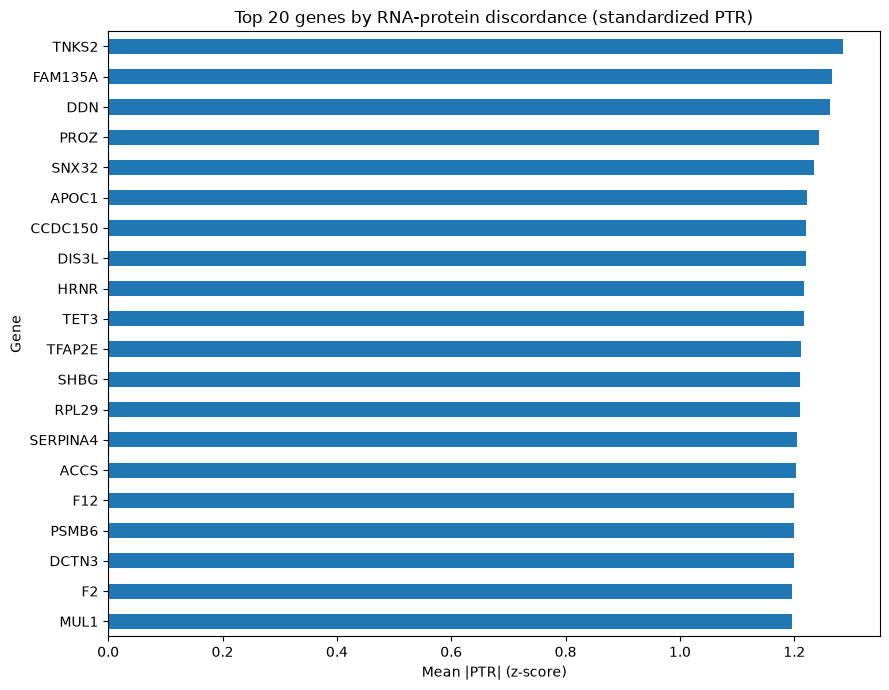

In [16]:
plt.figure(figsize=(9, 7))

top_genes_z.sort_values().plot(kind="barh")

plt.xlabel("Mean |PTR| (z-score)")
plt.ylabel("Gene")
plt.title("Top 20 genes by RNA-protein discordance (standardized PTR)")

plt.tight_layout()
plt.show()

Résultat principal :

top PTR genes
graphique

# Section 3 — RNA-to-protein prediction model
Entraîner un modèle par gène

L'idée :

Pour chaque gène :

Protein=f(RNA)

Le modèle apprend la relation normale.

Puis :

Residual=Proteinobserve −Proteinpredit

Les gros résidus = régulation post-transcriptionnelle.

Pour commencer simplement :

"MAE quantifies the average prediction error when protein abundance is estimated from mRNA expression. Genes with higher MAE show weaker RNA-protein coupling and represent candidates for post-transcriptional regulation."

MAE signifie Mean Absolute Error (erreur absolue moyenne).

Dans ton contexte, il mesure à quel point ton modèle se trompe quand il essaie de prédire la quantité de protéine à partir du niveau d'ARN.

Dans ton modèle :

Tu fais :

RNA→modele→proteine predite

Pour chaque patient, tu compares :

la vraie valeur protéique mesurée par CPTAC
la valeur protéique prédite par le modèle

La différence est appelée erreur (résidu) :

Erreur=Proteine reelle−Proteine predite

Comme certaines erreurs sont positives et d'autres négatives, on prend la valeur absolue :

∣Erreur∣

Puis on fait la moyenne :

MAE=1/n ∑∣Proteine reelle−Proteine predite∣

**MAE** signifie **Mean Absolute Error** (erreur absolue moyenne).

Dans ton contexte, il mesure **à quel point ton modèle se trompe quand il essaie de prédire la quantité de protéine à partir du niveau d'ARN**.

---

### Dans ton modèle :

Tu fais :

[
RNA \rightarrow modèle \rightarrow protéine\ prédite
]

Pour chaque patient, tu compares :

* la vraie valeur protéique mesurée par CPTAC
* la valeur protéique prédite par le modèle

La différence est appelée **erreur (résidu)** :

[
Erreur = Protéine\ réelle - Protéine\ prédite
]

Comme certaines erreurs sont positives et d'autres négatives, on prend la valeur absolue :

[
|Erreur|
]

Puis on fait la moyenne :

[
MAE = \frac{1}{n}\sum |Protéine\ réelle - Protéine\ prédite|
]

---

### Exemple simple

Imaginons le gène **TP53** chez 4 patients :

| Patient | Protéine réelle | Protéine prédite | Erreur absolue |
| ------- | --------------: | ---------------: | -------------: |
| P1      |              10 |               11 |              1 |
| P2      |              15 |               13 |              2 |
| P3      |               8 |                9 |              1 |
| P4      |              12 |               15 |              3 |

MAE :

[
(1+2+1+3)/4 = 1.75
]

Donc :

> En moyenne, le modèle se trompe de 1.75 unités protéiques.

---

### Dans ton projet :

Tu as obtenu :

| Gene  |  MAE |
| ----- | ---: |
| XAGE2 | 1.66 |
| FABP7 | 1.62 |
| MUC2  | 1.45 |

Cela veut dire :

* Pour **XAGE2**, même en connaissant son ARN, le modèle a une erreur moyenne de ~1.66 unités dans la prédiction de la protéine.
* Pour **MUC2**, l'erreur est plus faible (~1.45), donc la relation ARN → protéine est un peu plus prédictible.

---

### Pourquoi un MAE élevé peut indiquer une régulation post-transcriptionnelle ?

Parce que ton hypothèse est :

> Si l'ARN explique bien la quantité de protéine, alors la protéine devrait être prédictible à partir de l'ARN.

Donc :

* **MAE faible** → ARN explique bien la protéine → régulation post-transcriptionnelle probablement faible
* **MAE élevé** → ARN ne suffit pas à expliquer la protéine → il existe probablement d'autres mécanismes :

  * contrôle de la traduction
  * dégradation protéique
  * stabilité de l'ARN
  * modifications post-traductionnelles

---

Petite nuance importante : ton MAE est calculé dans **l'échelle des données protéomiques normalisées**, donc ce n'est pas "1.66 protéines en plus ou en moins". C'est **1.66 unités dans l'échelle CPTAC de l'intensité protéique normalisée**.

Dans ton notebook, tu peux le présenter comme :

> "MAE quantifies the average prediction error when protein abundance is estimated from mRNA expression. Genes with higher MAE show weaker RNA-protein coupling and represent candidates for post-transcriptional regulation."


Pour chaque gène, apprendre la relation ARN → protéine, puis mesurer à quel point la protéine réelle s'écarte de la protéine prédite.

In [17]:
rna_common
prot_common



Name,A1BG,A2M,A2ML1,AAAS,AACS,AADAT,AAGAB,AAK1,AAMDC,AAMP,...,ZSCAN31,ZSWIM8,ZSWIM9,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11B,ZYX,ZZEF1
Patient_ID,,,,,,,,,,,,,,,,,,,,,
01BR001,28.962261,29.779428,21.351352,24.221998,25.562177,20.804083,23.696172,24.366991,25.755985,24.552508,...,NaN,23.447637,NaN,25.011059,22.320031,21.018048,21.104439,21.911078,28.229316,23.801493
01BR008,27.839429,29.287993,23.739284,24.249476,24.889247,NaN,23.930467,24.191442,25.189179,24.792360,...,18.644766,23.380664,NaN,25.191417,22.500922,21.436995,20.797679,21.636444,27.769384,24.472764
01BR009,28.443568,30.365854,24.239299,23.983666,25.323589,NaN,23.531060,24.167906,25.419556,24.609729,...,18.635893,23.162930,NaN,25.114675,21.942634,20.913868,20.153627,21.883145,27.934871,24.378181
01BR010,27.795584,28.595986,21.038688,24.184251,27.157644,23.150449,23.788412,24.255199,26.392067,24.553659,...,19.436612,23.177238,17.748417,25.672750,21.314271,20.638140,19.571371,21.374358,28.464642,24.411154
01BR015,28.515077,28.963103,21.168247,24.460260,26.076591,19.880108,24.005592,24.186562,26.082522,24.784979,...,NaN,23.116295,NaN,24.975157,21.777809,21.543541,18.700396,21.737503,28.590138,24.023057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21BR002,27.584038,29.253790,21.733657,24.228747,24.810965,NaN,24.381621,24.387662,25.279403,24.782719,...,18.307238,23.239578,NaN,25.507774,21.897961,20.829177,19.955149,21.802583,28.054126,24.564800
21BR010,28.547955,29.268089,21.007601,23.970413,25.223990,19.796409,24.624261,24.691724,25.503017,25.004642,...,20.014745,23.378961,NaN,25.291145,21.026395,20.956806,19.497992,21.893004,28.237315,24.395581
22BR005,28.074586,28.804101,20.870967,24.101861,25.679819,19.739080,24.769452,24.517872,25.892148,25.678621,...,19.421218,23.300945,17.742610,24.837707,22.132496,21.548316,20.410010,21.658661,27.945885,24.404292


In [18]:
results = []

print("="*50 + "\n Training gene-wise RNA → protein prediction models \n" + "="*50)

for gene in keep_genes:

    # Predictor: mRNA expression
    X = rna_common[[gene]]

    # Target: protein abundance
    y = prot_common[gene]

    # Keep only samples with available protein measurements
    mask = y.notna()

    # minimum number of samples
    if mask.sum() < 80:
        continue

    model = LinearRegression()
    model.fit(
        X[mask], 
        y[mask])

    # Prediction and residual calculation
    pred = model.predict(
        X[mask])

    mae = mean_absolute_error(
        y[mask],
        pred
    )

    r2 = r2_score(
        y[mask],
        pred
    )
    
    residuals = y[mask] - pred

    results.append({
        "gene": gene,
        "MAE": round(mae,3),
        "R2": round(r2,3),
        "n_samples": mask.sum()
    })


model_results = pd.DataFrame(results)

print(
    f"Models trained for {len(model_results)} genes "
    f"using RNA expression to predict protein abundance."
)

display(
    model_results
    .sort_values("MAE", ascending=False)
    .head(20)
)

 Training gene-wise RNA → protein prediction models 
Models trained for 9360 genes using RNA expression to predict protein abundance.


,gene,MAE,R2,n_samples
9077,XAGE2,1.663,0.329,89
2673,FABP7,1.624,0.317,121
3713,IGHV1OR15-9,1.447,0.000,104
5007,MUC2,1.447,0.234,94
8268,TMA7,1.382,0.060,119
1141,CARTPT,1.343,0.247,121
5011,MUCL1,1.338,0.466,120
1467,CGA,1.329,0.279,96
3401,HBG1,1.301,0.035,90
7103,S100A7,1.291,0.435,120


For each gene, a linear regression model was trained to predict protein abundance from mRNA expression. The mean absolute error (MAE) quantifies how poorly protein levels can be explained by transcript abundance. Genes with the highest MAE represent candidates for strong post-transcriptional regulation.

In [19]:
# Discordance = fraction of protein variance NOT explained by mRNA (scale-free)
model_results["post_transcriptional_score"] = 1 - model_results["R2"]


top_candidates = (
    model_results
    .sort_values(
        "post_transcriptional_score",
        ascending=False
    )
    .head(20).round(2)
)



print("="*60)
print(" Strongest post-transcriptional regulation candidates ")
print("="*60)


display(top_candidates)

 Strongest post-transcriptional regulation candidates 


,gene,MAE,R2,n_samples,post_transcriptional_score
2993,GABARAP,0.49,0.0,121,1.0
2996,GABPB1,0.33,0.0,121,1.0
6906,RNPEPL1,0.23,0.0,84,1.0
6937,RPL18,0.31,0.0,121,1.0
1346,CDK10,0.48,0.0,91,1.0
9202,ZFAND2B,0.25,0.0,121,1.0
2583,ERH,0.23,0.0,121,1.0
5705,PCLO,0.62,0.0,86,1.0
2886,FKBP1B,0.31,0.0,98,1.0
9247,ZNF143,0.23,0.0,121,1.0


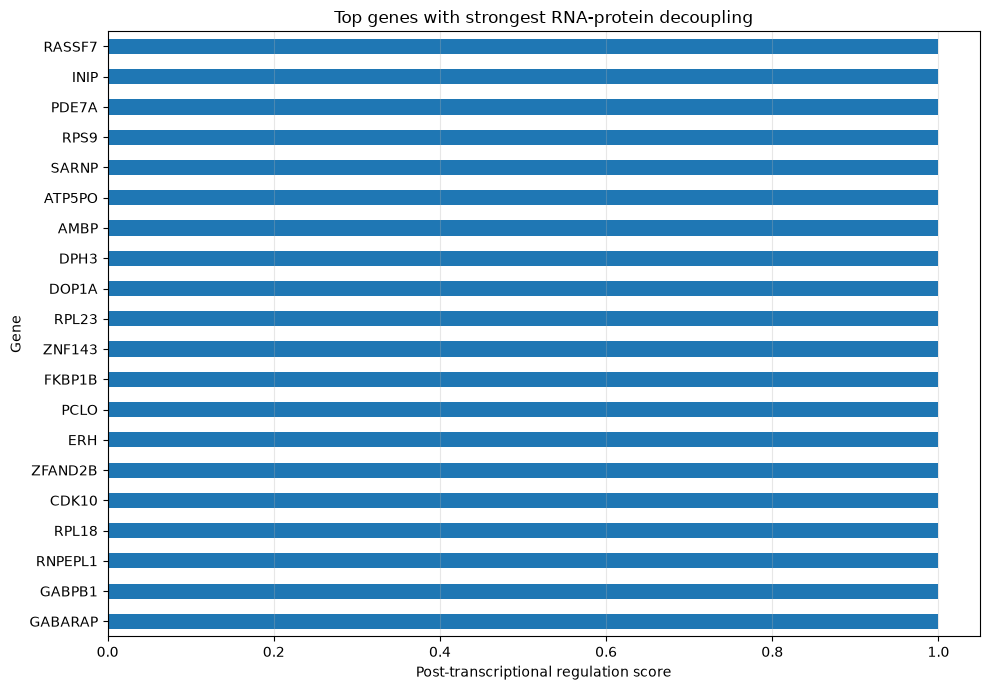

In [20]:
top_score_plot = (
    top_candidates
    .set_index("gene")["post_transcriptional_score"]
    .sort_values()
)


plt.figure(figsize=(10,7))

top_score_plot.plot(
    kind="barh"
)

plt.xlabel(
    "Post-transcriptional regulation score"
)

plt.ylabel(
    "Gene"
)

plt.title(
    "Top genes with strongest RNA-protein decoupling"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()

"Quels gènes sont les plus difficiles à prédire à partir de leur ARN ?"
Un MAE élevé signifie :

l'ARN ne permet pas de prédire précisément la protéine
la relation RNA-protéine est faible

C'est une analyse intéressante.

In [21]:
top_MAE = (
    model_results
    .sort_values("MAE", ascending=False)
    .head(20)
)

display(top_MAE)

,gene,MAE,R2,n_samples,post_transcriptional_score
9077,XAGE2,1.663,0.329,89,0.671
2673,FABP7,1.624,0.317,121,0.683
3713,IGHV1OR15-9,1.447,0.000,104,1.000
5007,MUC2,1.447,0.234,94,0.766
8268,TMA7,1.382,0.060,119,0.940
1141,CARTPT,1.343,0.247,121,0.753
5011,MUCL1,1.338,0.466,120,0.534
1467,CGA,1.329,0.279,96,0.721
3401,HBG1,1.301,0.035,90,0.965
7103,S100A7,1.291,0.435,120,0.565


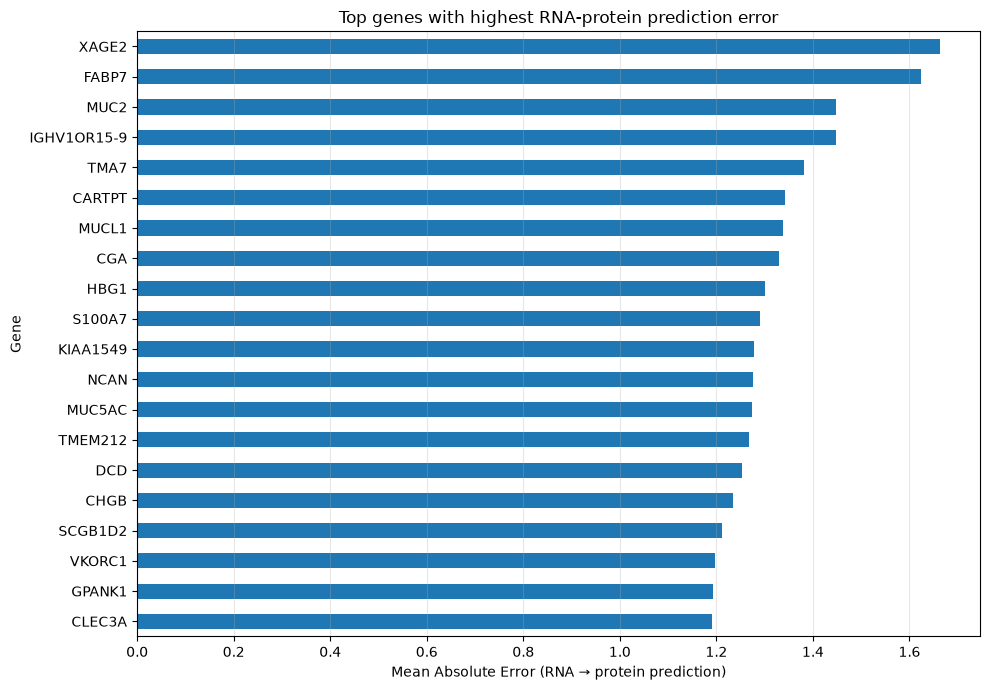

In [22]:
# Select top genes by MAE
top_MAE_plot = (
    top_MAE
    .set_index("gene")["MAE"]
    .sort_values()
)


plt.figure(figsize=(10, 7))

top_MAE_plot.plot(
    kind="barh"
)


plt.xlabel(
    "Mean Absolute Error (RNA → protein prediction)"
)

plt.ylabel(
    "Gene"
)

plt.title(
    "Top genes with highest RNA-protein prediction error"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()

modèle par gène
MAE

In [25]:
# Per-gene Spearman correlation between mRNA and protein across samples
gene_corr = rna_common.corrwith(prot_common, method="spearman")
# Post-transcriptional candidates = weakest RNA-protein coupling
candidates = gene_corr.sort_values().head(20)

F:\BD\ptr-proteogenomics-brca\.venv\Lib\site-packages\pandas\core\nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


# Section 4 — Comparaison PTR vs modèle Candidate post-transcriptional regulators

In [23]:
# Top genes according to the standardized  PTR deviation
top_ptr_genes = set(
    ptr_z_score
    .sort_values(ascending=False)
    .head(50)
    .index
)


# Top genes according to ML-based post-transcriptional score
top_ml_genes = set(
    model_results
    .sort_values(
        "post_transcriptional_score",
        ascending=False
    )
    .head(50)["gene"]
)


# Common genes identified by both approaches
overlap = top_ptr_genes.intersection(top_ml_genes)


print("="*60)
print(" Overlap between PTR and ML approaches ")
print("="*60)

print(
    f"Number of common genes: {len(overlap)}"
)
print(f"Overlap: {len(overlap) / len(top_ptr_genes) * 100:.1f}%")
print(
    sorted(overlap)
)

 Overlap between PTR and ML approaches 
Number of common genes: 1
Overlap: 2.0%
['DPH3']


Intersection PTR + MAE

Pour répondre à la question : PTR = analyse principale.
Pour renforcer l'analyse : modèle RNA→protéine + MAE en validation.

Ton projet devient alors une vraie analyse multi-omique plutôt qu'un simple calcul de ratio.

In [24]:
display(
    pd.DataFrame({
        "Gene": sorted(overlap)
    })
)

,Gene
0,DPH3


"Genes consistently identified by both direct PTR deviation and RNA-to-protein prediction failure represent the strongest candidates for post-transcriptional regulation in CPTAC-BRCA."